# 3a — Rotations: from scratch

Code companion to `notes/03a_rotations.md`. We implement, from scratch with
numpy, the core operations on `SO(3)`:

- rotation matrices as frames (and checking they're valid)
- the skew-symmetric operator `[ω]` (so(3)) and `ω × p`
- `exp([ω̂]θ)` — Rodrigues' formula (axis-angle → R)
- `log(R)` — recovering axis-angle from R
- a quick cross-check against the `modern_robotics` package

Read the note first if you haven't — this notebook assumes the intuition
built up there.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=3, suppress=True)

## 1. A rotation matrix is a frame's axes

Recreate the §2 example: `{b}` rotated 90° about the space z-axis. Check the
two defining properties of `SO(3)`: orthonormal columns (`RᵀR = I`) and
`det(R) = +1`.

In [2]:
theta0 = np.pi / 2
R_sb = np.array([
    [np.cos(theta0), -np.sin(theta0), 0],
    [np.sin(theta0),  np.cos(theta0), 0],
    [0,               0,              1],
])

print("R_sb =\n", R_sb)
print("\nR_sb.T @ R_sb (should be I):\n", R_sb.T @ R_sb)
print("\ndet(R_sb) =", np.linalg.det(R_sb))

R_sb =
 [[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

R_sb.T @ R_sb (should be I):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

det(R_sb) = 1.0


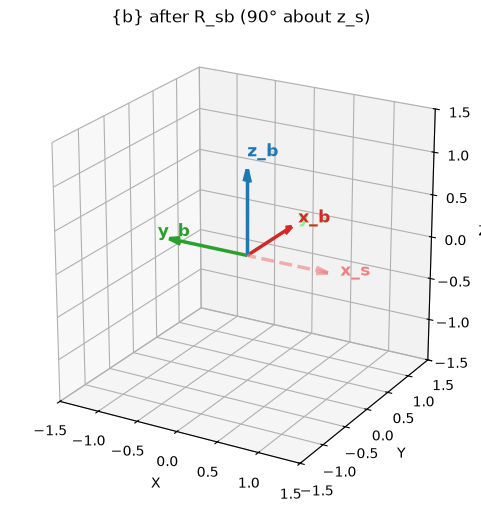

In [3]:
def draw_frame(ax, R, origin=(0, 0, 0), colors=("tab:red", "tab:green", "tab:blue"),
                labels=("x", "y", "z"), length=1.0, lw=2.5, style="-", alpha=1.0):
    """Plot R's columns as arrows from origin -- each column is a body axis."""
    o = np.array(origin, dtype=float)
    for i in range(3):
        axis = R[:, i] * length
        ax.quiver(*o, *axis, color=colors[i], linewidth=lw, linestyle=style,
                  alpha=alpha, arrow_length_ratio=0.15)
        ax.text(*(o + axis * 1.15), labels[i], color=colors[i], fontsize=12, fontweight="bold")


def setup_3d_axes(ax, lim=1.5, title=""):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title)
    ax.set_box_aspect([1, 1, 1])


fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
draw_frame(ax, np.eye(3), colors=("lightcoral", "lightgreen", "lightblue"),
           labels=("x_s", "y_s", "z_s"), style="--", alpha=0.6)
draw_frame(ax, R_sb, labels=("x_b", "y_b", "z_b"))
setup_3d_axes(ax, title="{b} after R_sb (90° about z_s)")
ax.view_init(elev=22, azim=-60)
plt.show()

## 2. The skew matrix `[ω]` and `ω × p`

`vec_to_so3` packs a 3-vector into its skew-symmetric matrix; `so3_to_vec` is
the inverse. Check `[ω]p = ω × p`.

In [4]:
def vec_to_so3(omega):
    """3-vector -> 3x3 skew-symmetric matrix [omega]."""
    omega = np.asarray(omega, dtype=float)
    return np.array([
        [0,         -omega[2],  omega[1]],
        [omega[2],   0,        -omega[0]],
        [-omega[1],  omega[0],  0],
    ])


def so3_to_vec(so3mat):
    """3x3 skew-symmetric matrix -> 3-vector. Inverse of vec_to_so3."""
    return np.array([so3mat[2, 1], so3mat[0, 2], so3mat[1, 0]])


omega = np.array([0.0, 0.0, 1.3])
p = np.array([1.0, 0.0, 0.3])

print("omega x p   =", np.cross(omega, p))
print("[omega] @ p =", vec_to_so3(omega) @ p)
print("round trip  =", so3_to_vec(vec_to_so3(omega)))

omega x p   = [0.  1.3 0. ]
[omega] @ p = [0.  1.3 0. ]
round trip  = [0.  0.  1.3]


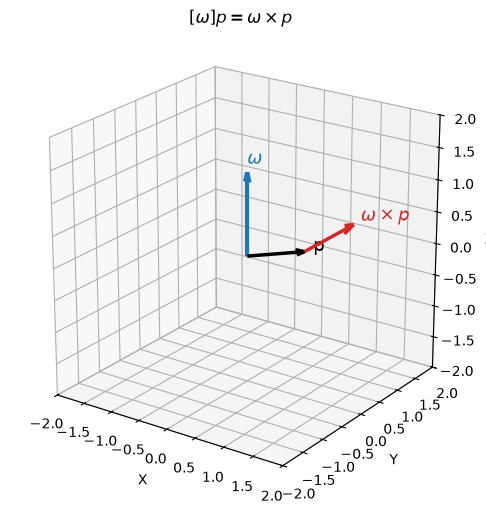

In [5]:
v = np.cross(omega, p)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.quiver(0, 0, 0, *omega, color="tab:blue", linewidth=3, arrow_length_ratio=0.12)
ax.text(*(omega * 1.1), r"$\omega$", color="tab:blue", fontsize=13)

ax.quiver(0, 0, 0, *p, color="black", linewidth=2.5, arrow_length_ratio=0.15)
ax.text(*(p * 1.15), "p", color="black", fontsize=13)

ax.quiver(*p, *v, color="tab:red", linewidth=2.5, arrow_length_ratio=0.2)
ax.text(*(p + v * 1.15), r"$\omega \times p$", color="tab:red", fontsize=13)

setup_3d_axes(ax, lim=2.0, title=r"$[\omega]p = \omega \times p$")
ax.view_init(elev=22, azim=-55)
plt.show()

## 3. Rodrigues' formula — `exp([ω̂]θ) → R`

```
R = I + sin(θ)[ω̂] + (1 − cos(θ))[ω̂]²
```

Check it reproduces `R_sb` for `ω̂ = (0,0,1)`, `θ = π/2`.

In [6]:
def matrix_exp3(omega_hat, theta):
    """Rodrigues' formula: axis omega_hat (unit vector) + angle theta -> R in SO(3)."""
    omg_mat = vec_to_so3(omega_hat)
    return np.eye(3) + np.sin(theta) * omg_mat + (1 - np.cos(theta)) * (omg_mat @ omg_mat)


R_check = matrix_exp3([0, 0, 1], np.pi / 2)
print("exp([z]*pi/2) =\n", R_check)
print("\nmatches R_sb:", np.allclose(R_check, R_sb))

exp([z]*pi/2) =
 [[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

matches R_sb: True


## 4. Watch a frame sweep through `exp([ω̂]θ)`

Same axis `ω̂`, increasing `θ` from 0 to π — the body frame rotates about
`ω̂` (dotted line), getting more solid (less transparent) as θ grows.

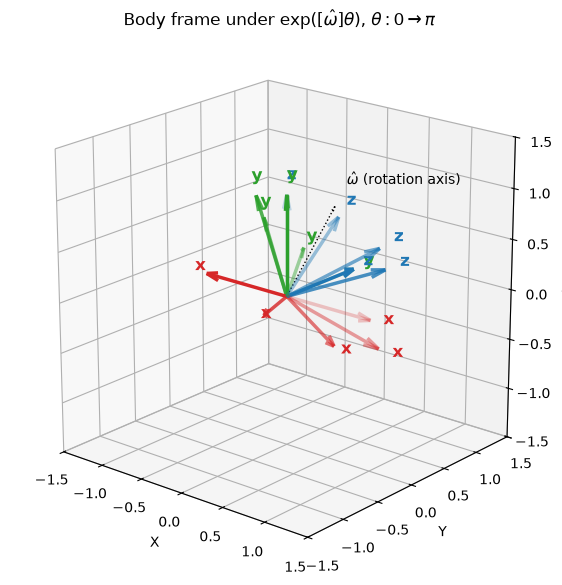

In [7]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

axis_hat = np.array([0, 1, 1]) / np.sqrt(2)
thetas = np.linspace(0, np.pi, 5)

for k, th in enumerate(thetas):
    R = matrix_exp3(axis_hat, th)
    alpha = 0.25 + 0.75 * k / (len(thetas) - 1)
    draw_frame(ax, R, alpha=alpha)

ax.quiver(0, 0, 0, *axis_hat, color="k", linewidth=1, linestyle=":", arrow_length_ratio=0.05)
ax.text(*(axis_hat * 1.25), r"$\hat{\omega}$ (rotation axis)", fontsize=10)

setup_3d_axes(ax, title=r"Body frame under exp($[\hat{\omega}]\theta$), $\theta: 0 \to \pi$")
ax.view_init(elev=20, azim=-50)
plt.show()

## 5. Matrix log — recovering axis-angle from `R`

```
θ = arccos((trace(R) − 1) / 2)
[ω̂] = (R − Rᵀ) / (2 sin θ)
```

with special handling at `θ ≈ 0` (any axis, no rotation) and `θ ≈ π`
(`sin θ ≈ 0`, use `(R+I)/2 = ω̂ω̂ᵀ` instead).

In [8]:
def matrix_log3(R):
    """R in SO(3) -> (omega_hat, theta). Inverse of matrix_exp3."""
    cos_theta = np.clip((np.trace(R) - 1) / 2, -1, 1)
    theta = np.arccos(cos_theta)

    if np.isclose(theta, 0):
        return np.zeros(3), 0.0

    if np.isclose(theta, np.pi):
        M = (R + np.eye(3)) / 2
        i = np.argmax(np.diag(M))  # avoid dividing by a near-zero entry
        col = M[:, i]
        omega_hat = col / np.sqrt(col[i])
        return omega_hat, theta

    omg_mat = (R - R.T) / (2 * np.sin(theta))
    return so3_to_vec(omg_mat), theta

In [9]:
rng = np.random.default_rng(0)

print("random axis/angle round trips:")
for _ in range(5):
    axis = rng.normal(size=3)
    axis /= np.linalg.norm(axis)
    theta = rng.uniform(0.1, np.pi - 0.1)

    R = matrix_exp3(axis, theta)
    axis_back, theta_back = matrix_log3(R)

    print(f"  theta {theta:.3f} -> {theta_back:.3f}   "
          f"axis match: {np.allclose(axis, axis_back)}")

print("\nedge cases:")
print("  theta=0:  ", matrix_log3(np.eye(3)))
R_pi = matrix_exp3([0, 0, 1], np.pi)
axis_pi, theta_pi = matrix_log3(R_pi)
print(f"  theta=pi: axis={axis_pi}, theta={theta_pi:.3f}")

random axis/angle round trips:
  theta 0.149 -> 0.149   axis match: True
  theta 2.246 -> 2.246   axis match: True
  theta 0.108 -> 0.108   axis match: True
  theta 0.617 -> 0.617   axis match: True
  theta 1.343 -> 1.343   axis match: True

edge cases:
  theta=0:   (array([0., 0., 0.]), 0.0)
  theta=pi: axis=[0. 0. 1.], theta=3.142


## 6. Cross-check against `modern_robotics`

The official package packs `(ω̂, θ)` together as **exponential coordinates**
`ω̂θ` (one 3-vector) rather than separately.

In [10]:
import modern_robotics as mrlib

omega_hat, theta = np.array([0.0, 0.0, 1.0]), np.pi / 3

R_ours = matrix_exp3(omega_hat, theta)
R_theirs = mrlib.MatrixExp3(vec_to_so3(omega_hat * theta))
print("MatrixExp3 match:", np.allclose(R_ours, R_theirs))

axis_ours, theta_ours = matrix_log3(R_ours)
so3mat_theirs = mrlib.MatrixLog3(R_ours)
expc3_theirs = mrlib.so3ToVec(so3mat_theirs)
axis_theirs, theta_theirs = mrlib.AxisAng3(expc3_theirs)

print("axis match: ", np.allclose(axis_ours, axis_theirs))
print("theta match:", np.allclose(theta_ours, theta_theirs))

MatrixExp3 match: True
axis match:  True
theta match: True


## Wrap-up

`vec_to_so3`, `so3_to_vec`, `matrix_exp3`, `matrix_log3` are promoted to
`mr/so3.py`; `draw_frame` / `setup_3d_axes` go to `mr/plotting.py` for reuse in
future notebooks — we'll need all of these constantly from Ch. 4 onward.

Next: **3b — rigid-body motions & twists (SE(3))**.